<p align="center">
    <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-SinFondo.png" width="500"/>
</p>

<h2 align="center"><i>ITESO, Universidad Jesuita de Guadalajara</i></h2>
<h2 align="center"><i>Quantitative Finance</i></h2>
<h2 align="center"><i>Prof. Luis Carlos Alvarado Garnica</i></h2>

# Heston — Análisis de Parámetros
---
En este notebook exploramos **cómo cada parámetro de Heston deforma la sonrisa de volatilidad implicita**. La meta no es solo ver las curvas, sino construir la *intuición* que después nos permitirá dar buenos valores iniciales al calibrador y diagnosticar malos ajustes.

| Parámetro | Mueve… | Afecta principalmente |
|-----------|---------|----------------------|
| $\rho$ | la pendiente del skew (inclinación) | asimetría de la sonrisa |
| $\xi$ | la curvatura (convexidad) | las alas (ITM/OTM profundo) |
| $v_0$ | el nivel de corto plazo | vencimientos cortos |
| $\theta$ | el nivel de largo plazo | vencimientos largos |
| $\kappa$ | la velocidad de la estructura temporal | qué tan rápido se aplana |

> **Idea rectora de la presentación 19:** $\rho$ *inclina* la sonrisa; $\xi$ la *dobla*. Juntos dan forma a toda la sección transversal.


## 0. Librerias

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
                     'axes.grid':True,'grid.alpha':0.35,'font.size':11,'lines.linewidth':2})

PURPLE='#534AB7'; GREEN='#1D9E75'; ORANGE='#D85A30'; AMBER='#BA7517'; BLUE='#2A7FBF'


## 1. Reutilizamos el motor de pricing de Heston

Estas son exactamente las mismas funciones del notebook `Heston_Call_Pricing.ipynb` (la función característica en forma estable + inversión de Fourier).


In [2]:
def heston_cf_j(u, j, x, v, tau, r, kappa, theta, xi, rho):
    """Funcion caracteristica de Heston, forma estable (Little Trap)."""
    i  = 1j
    uj = 0.5             if j == 1 else -0.5
    bj = kappa - rho*xi  if j == 1 else  kappa
    dj  = np.sqrt((rho*xi*i*u - bj)**2 + xi**2*(u**2 - 2*uj*i*u))
    g2j = (bj - rho*xi*i*u + dj) / (bj - rho*xi*i*u - dj)
    Dj = ((bj - rho*xi*i*u + dj)/xi**2) * ((1-np.exp(dj*tau))/(1-g2j*np.exp(dj*tau)))
    Cj = r*i*u*tau + (kappa*theta/xi**2)*((bj-rho*xi*i*u+dj)*tau
                     - 2*np.log((1-g2j*np.exp(dj*tau))/(1-g2j)))
    return np.exp(Cj + Dj*v + i*u*x)

def heston_prob_j(j, x, v, tau, K, r, kappa, theta, xi, rho):
    lnK = np.log(K)
    integrand = lambda u: np.real(np.exp(-1j*u*lnK)*heston_cf_j(u,j,x,v,tau,r,kappa,theta,xi,rho)/(1j*u))
    val, _ = quad(integrand, 1e-8, 200, limit=200)
    return 0.5 + val/np.pi

def heston_call(S, K, r, tau, v0, kappa, theta, xi, rho):
    x  = np.log(S)
    P1 = heston_prob_j(1, x, v0, tau, K, r, kappa, theta, xi, rho)
    P2 = heston_prob_j(2, x, v0, tau, K, r, kappa, theta, xi, rho)
    return S*P1 - K*np.exp(-r*tau)*P2

def bs_call(S, K, r, tau, sigma):
    d1=(np.log(S/K)+(r+0.5*sigma**2)*tau)/(sigma*np.sqrt(tau)); d2=d1-sigma*np.sqrt(tau)
    return S*norm.cdf(d1)-K*np.exp(-r*tau)*norm.cdf(d2)

def bs_implied_vol(price, S, K, r, tau, tol=1e-7):
    intr = max(S-K*np.exp(-r*tau), 0.0)
    if price <= intr + 1e-8: return np.nan
    lo, hi = 1e-6, 5.0
    for _ in range(100):
        mid=(lo+hi)/2; d=bs_call(S,K,r,tau,mid)-price
        if abs(d)<tol: return mid
        lo,hi=(mid,hi) if d<0 else (lo,mid)
    return mid


## 2. Parámetros base

Estos valores **no** están calibrados a ningún mercado: son un punto de partida ilustrativo, elegido para dar un skew reconocible tipo equity.


In [3]:
S0, r, T = 100.0, 0.02, 1.0

v0_base    = 0.04
theta_base = 0.04
kappa_base = 1.5
xi_base    = 0.5
rho_base   = -0.7

strikes = np.linspace(70, 130, 30)
logm    = np.log(strikes / S0)

def smile(v0, theta, kappa, xi, rho, T=T):
    """Devuelve la vol implicita (%) en cada strike para los parametros dados."""
    ivs = []
    for K in strikes:
        p = heston_call(S0, K, r, T, v0, kappa, theta, xi, rho)
        ivs.append(bs_implied_vol(p, S0, K, r, T)*100)
    return np.array(ivs)

base = smile(v0_base, theta_base, kappa_base, xi_base, rho_base)
print("Sonrisa base calculada. Vol ATM =", round(base[np.argmin(np.abs(strikes-S0))],2), "%")


Sonrisa base calculada. Vol ATM = 18.43 %


## 3. Efecto de $\rho$ — la correlación controla el *skew*

$\rho$ es el driver **primario de la pendiente**. Cuando $\rho<0$, las caidas de precio vienen acompañadas de subidas de varianza: los movimientos a la baja son más volátiles, la cola izquierda engorda, y la vol implicita sube en los strikes bajos. Eso inclina la sonrisa hacia abajo — la forma tipica de los indices accionarios.


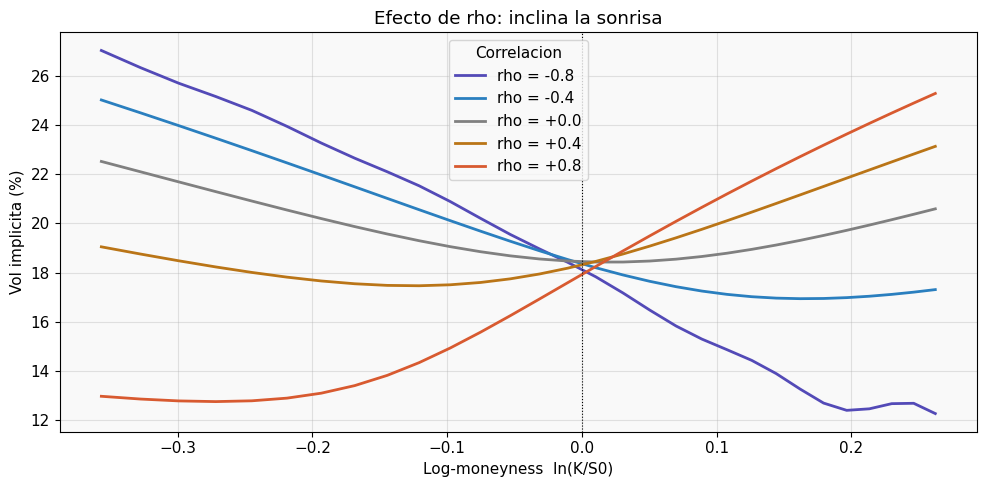

In [4]:
fig, ax = plt.subplots(figsize=(10,5))
for rho_i, col in zip([-0.8,-0.4,0.0,0.4,0.8], [PURPLE,BLUE,'gray',AMBER,ORANGE]):
    ax.plot(logm, smile(v0_base,theta_base,kappa_base,xi_base,rho_i),
            color=col, label=f'rho = {rho_i:+.1f}')
ax.axvline(0, color='black', ls=':', lw=0.8)
ax.set_xlabel('Log-moneyness  ln(K/S0)'); ax.set_ylabel('Vol implicita (%)')
ax.set_title('Efecto de rho: inclina la sonrisa'); ax.legend(title='Correlacion')
plt.tight_layout(); plt.show()


## 4. Efecto de $\xi$ — la vol-de-vol controla la curvatura

Mayor $\xi$ significa que la varianza fluctúa más, lo que engorda **ambas** colas y produce una sonrisa más convexa. Cuando $\xi \to 0$, la sonrisa se aplana hacia la linea recta de Black-Scholes. $\xi$ afecta sobre todo las **alas**, poco el nivel ATM.


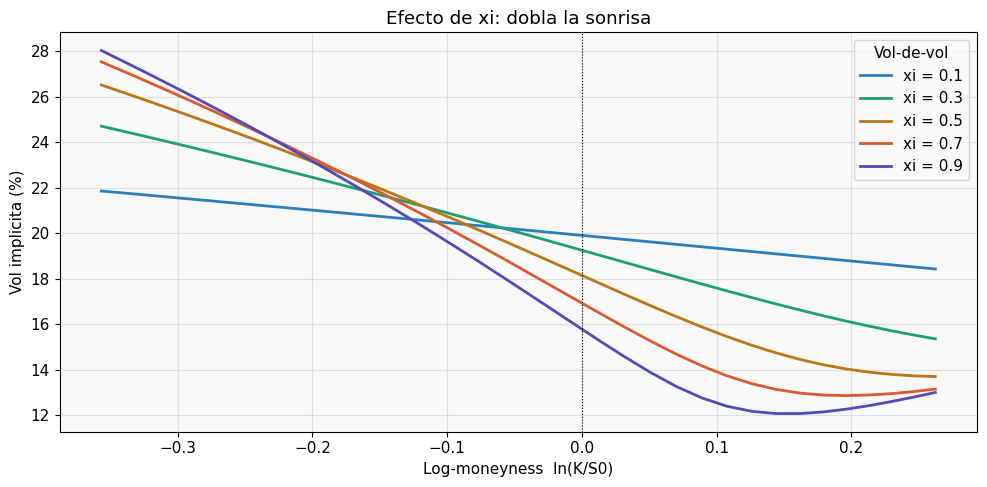

In [5]:
fig, ax = plt.subplots(figsize=(10,5))
for xi_i, col in zip([0.1,0.3,0.5,0.7,0.9], [BLUE,GREEN,AMBER,ORANGE,PURPLE]):
    ax.plot(logm, smile(v0_base,theta_base,kappa_base,xi_i,rho_base),
            color=col, label=f'xi = {xi_i:.1f}')
ax.axvline(0, color='black', ls=':', lw=0.8)
ax.set_xlabel('Log-moneyness  ln(K/S0)'); ax.set_ylabel('Vol implicita (%)')
ax.set_title('Efecto de xi: dobla la sonrisa'); ax.legend(title='Vol-de-vol')
plt.tight_layout(); plt.show()


## 5. Efecto de $v_0$ y $\theta$ — el nivel (corto vs largo plazo)

- $\sqrt{v_0}$ es, aproximadamente, la vol ATM cuando $T\to 0$ (nivel de **corto** plazo).
- $\sqrt{\theta}$ es la vol ATM cuando $T\to\infty$ (nivel de **largo** plazo).

Aqui los movemos y vemos cómo suben o bajan el nivel general de la sonrisa.


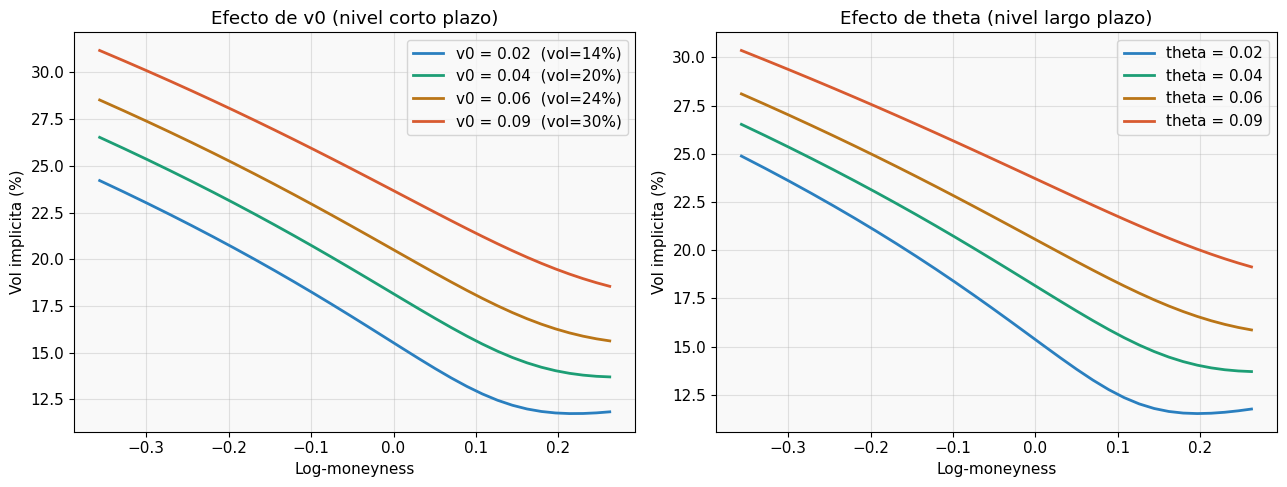

In [6]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
for v0_i, col in zip([0.02,0.04,0.06,0.09],[BLUE,GREEN,AMBER,ORANGE]):
    axes[0].plot(logm, smile(v0_i,theta_base,kappa_base,xi_base,rho_base),
                 color=col, label=f'v0 = {v0_i:.2f}  (vol={np.sqrt(v0_i):.0%})')
axes[0].set_title('Efecto de v0 (nivel corto plazo)')
axes[0].set_xlabel('Log-moneyness'); axes[0].set_ylabel('Vol implicita (%)'); axes[0].legend()

for th_i, col in zip([0.02,0.04,0.06,0.09],[BLUE,GREEN,AMBER,ORANGE]):
    axes[1].plot(logm, smile(v0_base,th_i,kappa_base,xi_base,rho_base),
                 color=col, label=f'theta = {th_i:.2f}')
axes[1].set_title('Efecto de theta (nivel largo plazo)')
axes[1].set_xlabel('Log-moneyness'); axes[1].set_ylabel('Vol implicita (%)'); axes[1].legend()
plt.tight_layout(); plt.show()


## 6. Sonrisa interactiva — mueve los sliders

Esta es la celda central de la sesión. Mueve cada slider y observa en tiempo real cómo se deforma la sonrisa. La curva gris punteada es siempre la sonrisa **base**, para tener una referencia fija contra la cual comparar.

**Sugerencia de exploración en clase:**
1. Deja todo fijo y mueve solo $\rho$ de $-0.9$ a $+0.9$: observa cómo *gira* la sonrisa.
2. Regresa $\rho$ a la base y ahora sube $\xi$: observa cómo *se curva* sin girar.
3. Sube $v_0$: toda la curva sube en bloque.

> **Nota:** requiere `ipywidgets`. Si no corre, instala con `pip install ipywidgets` y reinicia el kernel.


In [7]:
def plot_interactive_smile(v0=0.04, theta=0.04, kappa=1.5, xi=0.5, rho=-0.7):
    ivs = smile(v0, theta, kappa, xi, rho)
    fig, ax = plt.subplots(figsize=(10,5.5))
    ax.plot(logm, base, color='gray', ls='--', lw=1.5, alpha=0.7, label='Sonrisa base')
    ax.plot(logm, ivs,  color=ORANGE, lw=2.5, label='Sonrisa actual')
    ax.axvline(0, color='black', ls=':', lw=0.8)
    ax.set_xlabel('Log-moneyness  ln(K/S0)'); ax.set_ylabel('Vol implicita (%)')
    ax.set_ylim(8, 40)
    feller = 2*kappa*theta >= xi**2
    estado = 'CUMPLE' if feller else 'VIOLADA'
    ax.set_title(f'Sonrisa de Heston  |  Feller 2kappa*theta={2*kappa*theta:.3f} vs xi^2={xi**2:.3f}: {estado}')
    ax.legend(loc='upper right')
    plt.tight_layout(); plt.show()

interact(plot_interactive_smile,
         v0    = FloatSlider(min=0.01, max=0.15, step=0.005, value=0.04, description='v0'),
         theta = FloatSlider(min=0.01, max=0.15, step=0.005, value=0.04, description='theta'),
         kappa = FloatSlider(min=0.2,  max=5.0,  step=0.1,   value=1.5,  description='kappa'),
         xi    = FloatSlider(min=0.05, max=1.2,  step=0.05,  value=0.5,  description='xi'),
         rho   = FloatSlider(min=-0.95,max=0.95, step=0.05,  value=-0.7, description='rho'));


interactive(children=(FloatSlider(value=0.04, description='v0', max=0.15, min=0.01, step=0.005), FloatSlider(v…

## 7. La condición de Feller y la tensión con la sonrisa

Una sonrisa pronunciada (skew empinado, fuerte curvatura) suele requerir **$\xi$ grande** y **$\rho$ muy negativo**. Pero un $\xi$ grande empuja contra la condición de Feller $2\kappa\theta \geq \xi^2$.

En la práctica, los parámetros calibrados a mercados accionarios **rutinariamente violan Feller**. Esto es aceptable: solo significa que $v_t$ puede tocar cero. El pricing por función caracteristica no se ve afectado — el problema es puramente numérico y aparece solo al simular con Monte Carlo (lo veremos en la sesión de implementación robusta).


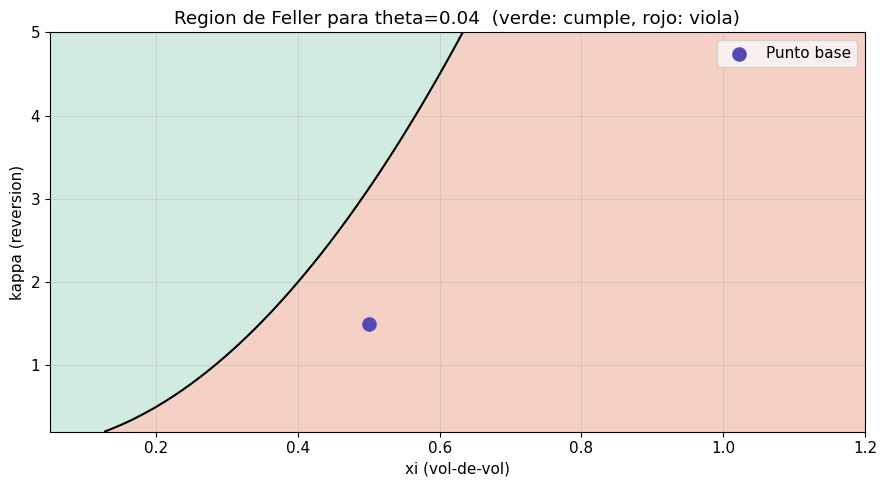

In [8]:
# Mapa de la region de Feller en el plano (xi, kappa) para theta base
xis   = np.linspace(0.05, 1.2, 100)
kaps  = np.linspace(0.2, 5.0, 100)
XI, KA = np.meshgrid(xis, kaps)
feller_ok = (2*KA*theta_base >= XI**2).astype(float)

fig, ax = plt.subplots(figsize=(9,5))
ax.contourf(XI, KA, feller_ok, levels=[-0.5,0.5,1.5],
            colors=['#f5c6b8','#c9e8dc'], alpha=0.8)
ax.contour(XI, KA, 2*KA*theta_base - XI**2, levels=[0], colors='black', linewidths=1.5)
ax.scatter([xi_base],[kappa_base], color=PURPLE, s=90, zorder=5, label='Punto base')
ax.set_xlabel('xi (vol-de-vol)'); ax.set_ylabel('kappa (reversion)')
ax.set_title(f'Region de Feller para theta={theta_base}  (verde: cumple, rojo: viola)')
ax.legend()
plt.tight_layout(); plt.show()


## 8. Resumen de la sesión

| Parámetro | Efecto en la sonrisa |
|-----------|---------------------|
| $\rho$ | **Inclina** (skew). Negativo = tipico equity |
| $\xi$ | **Dobla** (curvatura). Grande = alas más altas |
| $v_0$ | Nivel de **corto** plazo |
| $\theta$ | Nivel de **largo** plazo |
| $\kappa$ | Velocidad con que la estructura temporal se aplana |

**Heurística de calibración (presentación 19):** usa la estructura temporal ATM para fijar $v_0, \theta, \kappa$; usa la pendiente del skew para fijar $\rho$; usa la curvatura de las alas para fijar $\xi$. El optimizador refina los cinco juntos — ese es el tema de las siguientes dos sesiones.

> **Advertencia de identificabilidad:** $\kappa$ y $\xi$ son parcialmente redundantes: distintos pares $(\kappa,\xi)$ pueden producir casi la misma superficie. Esto vuelve la calibración mal condicionada — lo retomaremos en Calibration II.
